In [3]:
import pandas as pd
import plotly.graph_objects as go

# -----------------------
# Load data
# -----------------------

prices = pd.read_csv("../data/raw_data.csv", index_col=0, parse_dates=True)
returns = pd.read_csv("../data/log_returns.csv", index_col=0, parse_dates=True)

# -----------------------
# Plot prices
# -----------------------

fig_prices = go.Figure()

for col in prices.columns:
    fig_prices.add_trace(
        go.Scatter(
            x=prices.index,
            y=prices[col],
            mode="lines",
            name=col
        )
    )

fig_prices.update_layout(
    title="Asset Prices",
    xaxis_title="Date",
    yaxis_title="Price",
    template="plotly_white"
)

fig_prices.show()


# -----------------------
# Plot returns
# -----------------------

fig_returns = go.Figure()

for col in returns.columns:
    fig_returns.add_trace(
        go.Scatter(
            x=returns.index,
            y=returns[col],
            mode="lines",
            name=col
        )
    )

fig_returns.update_layout(
    title="Log Returns",
    xaxis_title="Date",
    yaxis_title="Return",
    template="plotly_white"
)

fig_returns.show()

In [4]:
import pandas as pd
from scipy.stats import skew, kurtosis

# -----------------------
# Load returns
# -----------------------

returns = pd.read_csv("../data/log_returns.csv", index_col=0, parse_dates=True)

# -----------------------
# Desired column order
# -----------------------

asset_order = [
    "US_EQUITY",
    "INTL_EQUITY",
    "US_BONDS",
    "INTL_BONDS",
    "US_REIT",
    "INTL_REIT",
    "GOLD",
    "BTC"
]

returns = returns[asset_order]

# -----------------------
# Compute statistics
# -----------------------

summary_stats = pd.DataFrame({
    "Mean": returns.mean(),
    "Std": returns.std(),
    "Min": returns.min(),
    "Max": returns.max(),
    "Skew": returns.apply(skew),
    "Excess Kurtosis": returns.apply(lambda x: kurtosis(x, fisher=True))
})

# -----------------------
# Print table
# -----------------------

print(summary_stats.round(4))

               Mean     Std     Min     Max    Skew  Excess Kurtosis
US_EQUITY    0.0006  0.0119 -0.1230  0.0909 -0.6709          15.5572
INTL_EQUITY  0.0003  0.0109 -0.1218  0.0797 -1.2186          17.9323
US_BONDS     0.0001  0.0035 -0.0408  0.0234 -1.1502          18.9432
INTL_BONDS   0.0001  0.0026 -0.0213  0.0238 -0.1035           8.7730
US_REIT      0.0002  0.0134 -0.1848  0.0819 -1.4915          23.7838
INTL_REIT    0.0001  0.0106 -0.1126  0.0812 -1.1550          16.9932
GOLD         0.0005  0.0093 -0.0641  0.0441 -0.3734           3.3989
BTC          0.0020  0.0430 -0.4647  0.2251 -0.5906           9.9357


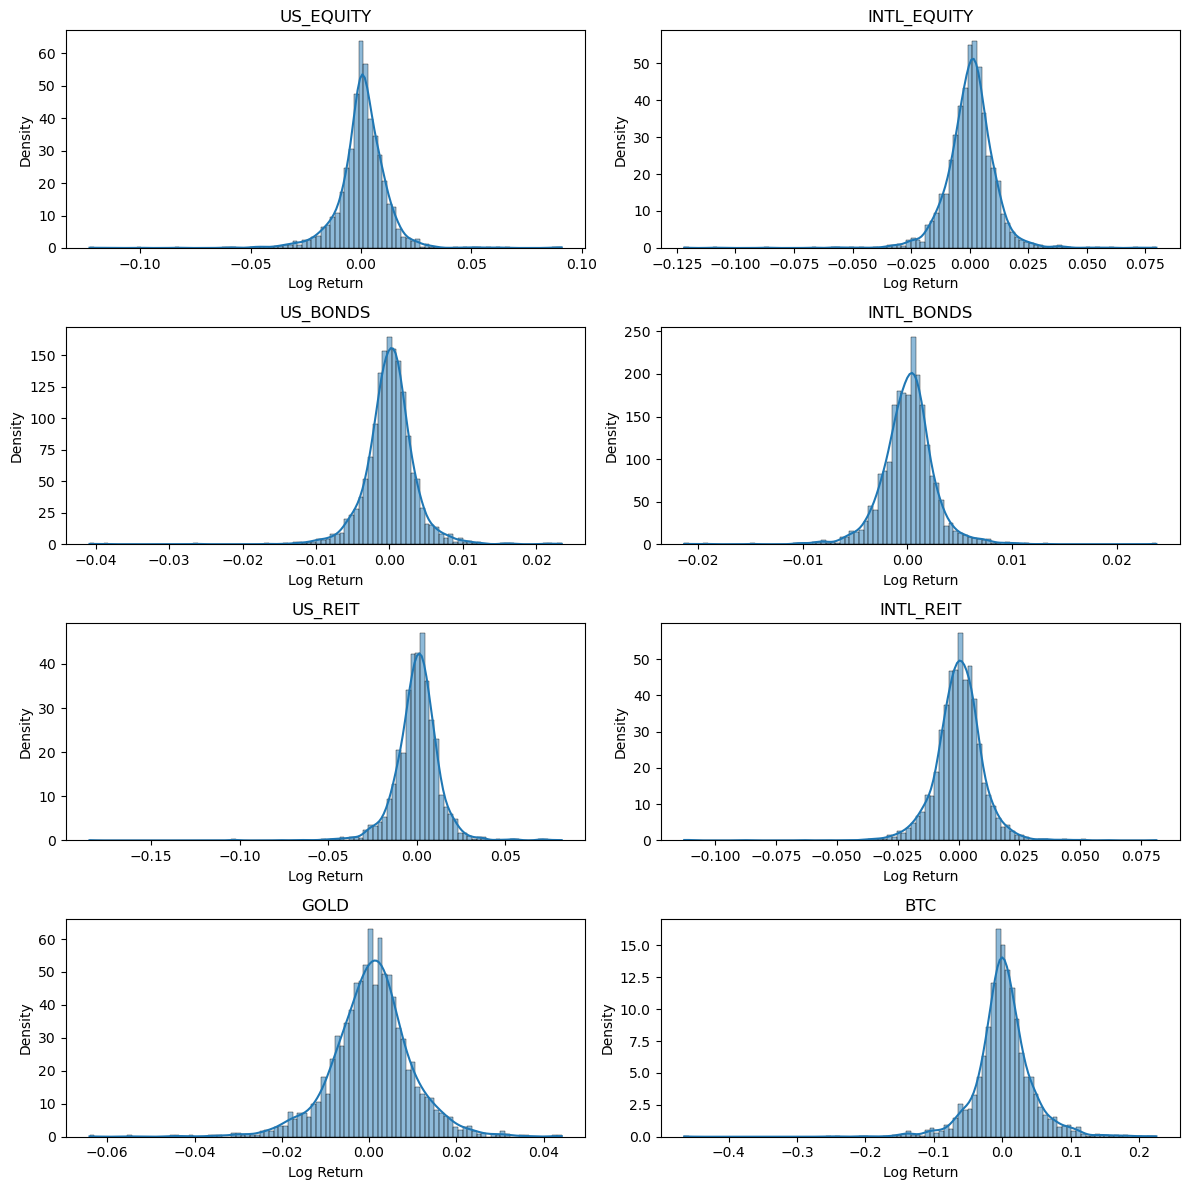

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------
# Load returns
# -----------------------

returns = pd.read_csv("../data/log_returns.csv", index_col=0, parse_dates=True)

# Asset order
asset_order = [
    "US_EQUITY",
    "INTL_EQUITY",
    "US_BONDS",
    "INTL_BONDS",
    "US_REIT",
    "INTL_REIT",
    "GOLD",
    "BTC"
]

returns = returns[asset_order]

# -----------------------
# Plot distributions
# -----------------------

fig, axes = plt.subplots(4, 2, figsize=(12, 12))
axes = axes.flatten()

for i, col in enumerate(returns.columns):
    
    sns.histplot(
        returns[col],
        bins=100,
        kde=True,
        stat="density",
        ax=axes[i]
    )
    
    axes[i].set_title(col)
    axes[i].set_xlabel("Log Return")
    axes[i].set_ylabel("Density")

plt.tight_layout()
plt.show()



In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# -----------------------
# Load returns
# -----------------------

returns = pd.read_csv("../data/log_returns.csv", index_col=0, parse_dates=True)

asset_order = [
    "US_EQUITY",
    "INTL_EQUITY",
    "US_BONDS",
    "INTL_BONDS",
    "US_REIT",
    "INTL_REIT",
    "GOLD",
    "BTC"
]

returns = returns[asset_order]

# -----------------------
# Correlation matrix
# -----------------------

corr_matrix = returns.corr()

print(corr_matrix.round(3))

             US_EQUITY  INTL_EQUITY  US_BONDS  INTL_BONDS  US_REIT  INTL_REIT  \
US_EQUITY        1.000        0.860     0.126       0.080    0.746      0.664   
INTL_EQUITY      0.860        1.000     0.197       0.118    0.703      0.813   
US_BONDS         0.126        0.197     1.000       0.716    0.287      0.304   
INTL_BONDS       0.080        0.118     0.716       1.000    0.234      0.240   
US_REIT          0.746        0.703     0.287       0.234    1.000      0.717   
INTL_REIT        0.664        0.813     0.304       0.240    0.717      1.000   
GOLD             0.088        0.219     0.337       0.256    0.151      0.253   
BTC              0.275        0.283     0.105       0.063    0.195      0.222   

              GOLD    BTC  
US_EQUITY    0.088  0.275  
INTL_EQUITY  0.219  0.283  
US_BONDS     0.337  0.105  
INTL_BONDS   0.256  0.063  
US_REIT      0.151  0.195  
INTL_REIT    0.253  0.222  
GOLD         1.000  0.103  
BTC          0.103  1.000  


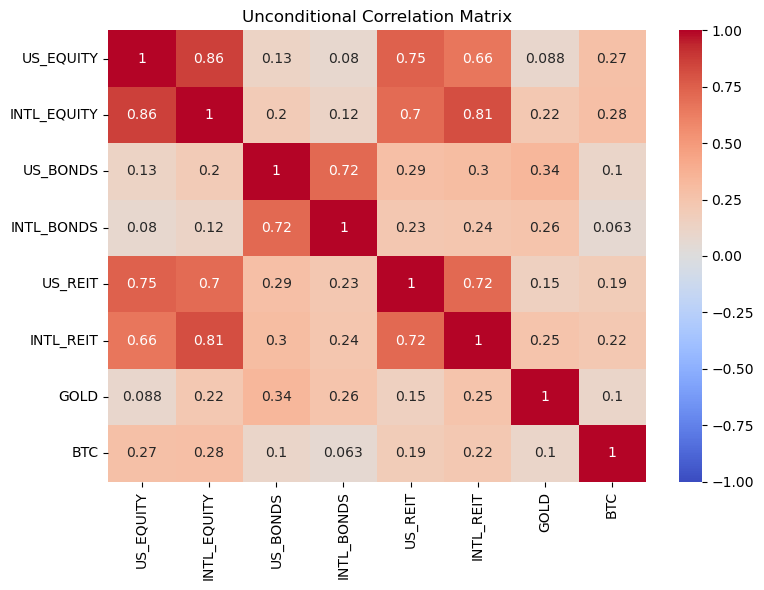

In [7]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1
)

plt.title("Unconditional Correlation Matrix")
plt.tight_layout()
plt.show()

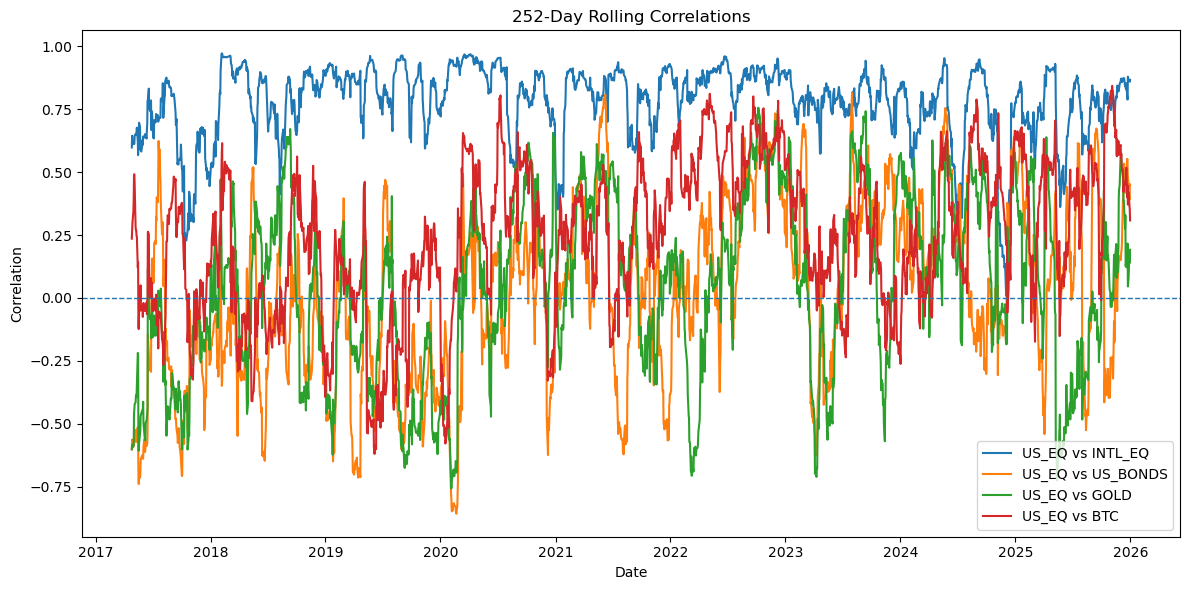

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------
# Load returns
# -----------------------
returns = pd.read_csv("../data/log_returns.csv", index_col=0, parse_dates=True)

# Rolling window (1 year)
window = 21


# Compute rolling correlations
rolling_corr = pd.DataFrame({
    "US_EQ vs INTL_EQ":
        returns["US_EQUITY"].rolling(window).corr(returns["INTL_EQUITY"]),
    
    "US_EQ vs US_BONDS":
        returns["US_EQUITY"].rolling(window).corr(returns["US_BONDS"]),
    
    "US_EQ vs GOLD":
        returns["US_EQUITY"].rolling(window).corr(returns["GOLD"]),
    
    "US_EQ vs BTC":
        returns["US_EQUITY"].rolling(window).corr(returns["BTC"])
})

# -----------------------
# Plot
# -----------------------
plt.figure(figsize=(12,6))

for col in rolling_corr.columns:
    plt.plot(rolling_corr.index, rolling_corr[col], label=col)

plt.axhline(0, linestyle="--", linewidth=1)
plt.title("252-Day Rolling Correlations")
plt.ylabel("Correlation")
plt.xlabel("Date")
plt.legend()
plt.tight_layout()
plt.show()

In [10]:
import pandas as pd
import numpy as np

from scipy.stats import jarque_bera
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch

# -----------------------
# Load returns
# -----------------------
returns = pd.read_csv("../data/log_returns.csv", index_col=0, parse_dates=True)

asset_order = [
    "US_EQUITY",
    "INTL_EQUITY",
    "US_BONDS",
    "INTL_BONDS",
    "US_REIT",
    "INTL_REIT",
    "GOLD",
    "BTC"
]
returns = returns[asset_order].dropna()

# -----------------------
# Test settings
# -----------------------
lb_lags = 20          # common choice for daily data
arch_lags = 10        # common choice for ARCH LM
adf_reg = "c"         # constant only; returns typically mean-stationary

# -----------------------
# Run tests
# -----------------------
rows = []
for col in asset_order:
    x = returns[col].dropna().astype(float)

    # ADF (stationarity)
    adf_stat, adf_p, *_ = adfuller(x.values, regression=adf_reg, autolag="AIC")

    # Jarque-Bera (normality)
    jb_stat, jb_p = jarque_bera(x.values)

    # Ljung-Box (serial dependence)
    lb_ret = acorr_ljungbox(x.values, lags=[lb_lags], return_df=True)
    lb_ret_stat = float(lb_ret["lb_stat"].iloc[0])
    lb_ret_p = float(lb_ret["lb_pvalue"].iloc[0])

    # Ljung-Box on squared returns (volatility clustering)
    lb_sq = acorr_ljungbox((x.values**2), lags=[lb_lags], return_df=True)
    lb_sq_stat = float(lb_sq["lb_stat"].iloc[0])
    lb_sq_p = float(lb_sq["lb_pvalue"].iloc[0])

    # ARCH LM (conditional heteroskedasticity)
    arch_lm_stat, arch_lm_p, *_ = het_arch(x.values, nlags=arch_lags)

    rows.append({
        "Mean": x.mean(),
        "Std": x.std(ddof=1),
        "Min": x.min(),
        "Max": x.max(),
        "Skew": x.skew(),
        "Excess Kurtosis": x.kurtosis(),  # pandas uses excess kurtosis by default
        "JB stat": jb_stat,
        "JB p": jb_p,
        "ADF stat": adf_stat,
        "ADF p": adf_p,
        f"LB({lb_lags}) stat": lb_ret_stat,
        f"LB({lb_lags}) p": lb_ret_p,
        f"LB²({lb_lags}) stat": lb_sq_stat,
        f"LB²({lb_lags}) p": lb_sq_p,
        f"ARCH({arch_lags}) LM stat": float(arch_lm_stat),
        f"ARCH({arch_lags}) p": float(arch_lm_p),
        "N": int(x.shape[0]),
    })

diagnostics = pd.DataFrame(rows, index=asset_order)

# -----------------------
# Display + (optional) save
# -----------------------
with pd.option_context("display.max_columns", None):
    print(diagnostics.round(4))

# Optional: export to LaTeX / CSV
# diagnostics.round(4).to_latex("../results/diagnostics_table.tex")
# diagnostics.round(6).to_csv("../results/diagnostics_table.csv")

               Mean     Std     Min     Max    Skew  Excess Kurtosis  \
US_EQUITY    0.0006  0.0119 -0.1230  0.0909 -0.6714          15.5953   
INTL_EQUITY  0.0003  0.0109 -0.1218  0.0797 -1.2194          17.9757   
US_BONDS     0.0001  0.0035 -0.0408  0.0234 -1.1509          18.9890   
INTL_BONDS   0.0001  0.0026 -0.0213  0.0238 -0.1036           8.7956   
US_REIT      0.0002  0.0134 -0.1848  0.0819 -1.4926          23.8406   
INTL_REIT    0.0001  0.0106 -0.1126  0.0812 -1.1558          17.0345   
GOLD         0.0005  0.0093 -0.0641  0.0441 -0.3736           3.4093   
BTC          0.0020  0.0430 -0.4647  0.2251 -0.5910           9.9610   

                JB stat  JB p  ADF stat  ADF p  LB(20) stat  LB(20) p  \
US_EQUITY    22391.4686   0.0  -14.8614    0.0     293.4415    0.0000   
INTL_EQUITY  30075.9169   0.0  -15.2695    0.0     157.8483    0.0000   
US_BONDS     33439.7814   0.0  -18.7604    0.0      66.4320    0.0000   
INTL_BONDS    7071.8995   0.0  -26.6223    0.0      38.7043